In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
sns.set_style("darkgrid")

In [3]:
train = pd.read_csv("https://raw.githubusercontent.com/manasjadhav0086/retail-demand-forecasting/refs/heads/main/train.csv")
features = pd.read_csv("https://raw.githubusercontent.com/manasjadhav0086/retail-demand-forecasting/refs/heads/main/features.csv")
stores = pd.read_csv("https://raw.githubusercontent.com/manasjadhav0086/retail-demand-forecasting/refs/heads/main/stores.csv")

print(train.head())
print(features.head())
print(stores.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211

In [4]:
print(train.shape)
print(train.info())
print(train.isnull().sum())

(421570, 5)
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 17.3 MB
None
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


In [5]:
df = train.merge(features, on=["Store", "Date", "IsHoliday"])
df = df.merge(stores, on="Store")

print(df.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  2010-02-05      24924.50      False        42.31       2.572   
1      1     1  2010-02-12      46039.49       True        38.51       2.548   
2      1     1  2010-02-19      41595.55      False        39.93       2.514   
3      1     1  2010-02-26      19403.54      False        46.63       2.561   
4      1     1  2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106    A  15

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

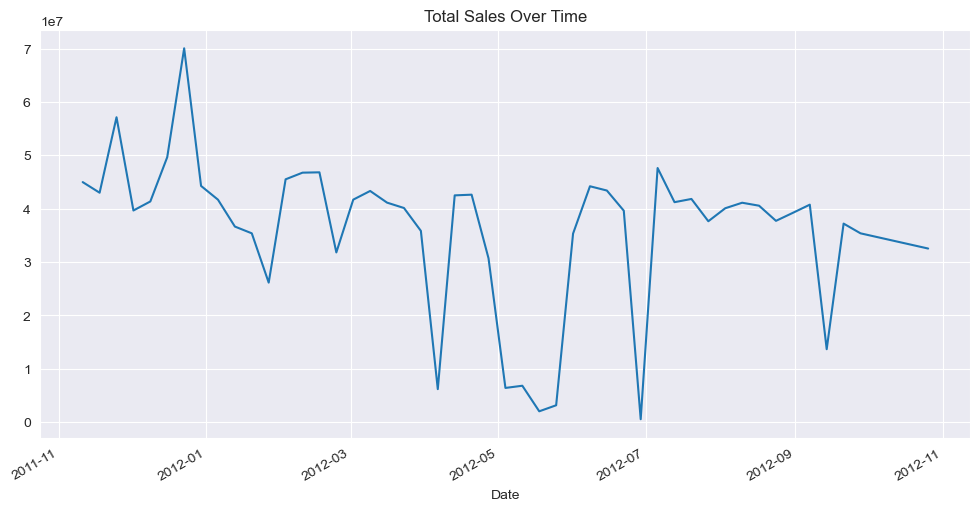

In [16]:
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
sales_trend.plot()
plt.title("Total Sales Over Time")
plt.show()

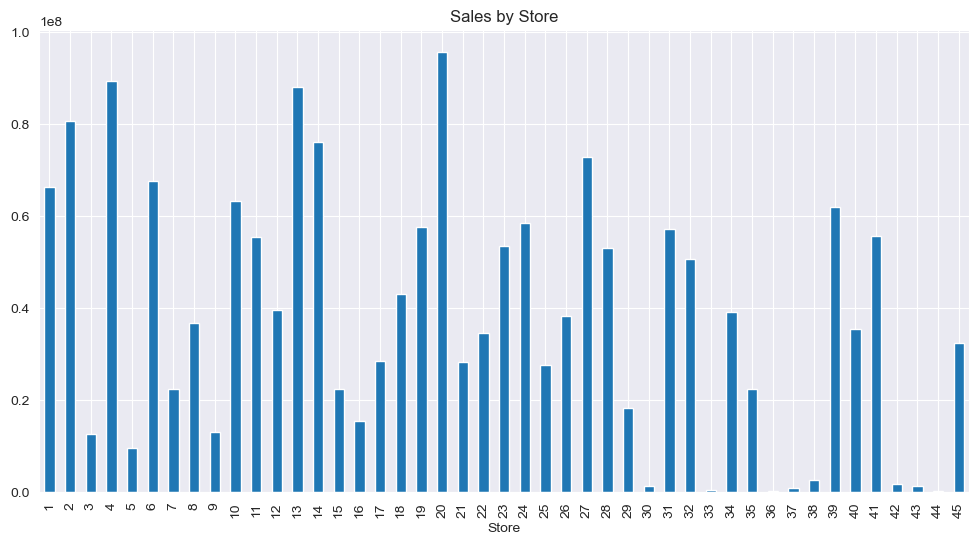

In [17]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
store_sales.plot(kind='bar')
plt.title("Sales by Store")
plt.show()

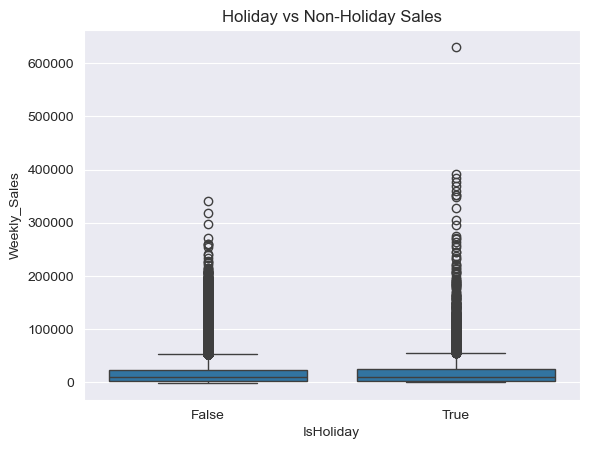

In [18]:
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)

plt.title("Holiday vs Non-Holiday Sales")
plt.show()

In [19]:
# Sort data
df = df.sort_values(["Store","Dept","Date"])

# Lag features
df["Lag_1"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(1)
df["Lag_2"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(2)

# Rolling average
df["Rolling_Mean"] = (
    df.groupby(["Store","Dept"])["Weekly_Sales"]
    .transform(lambda x: x.rolling(4).mean())
)

# Remove NaN rows created by lag/rolling
df = df.dropna()

In [21]:
feature_cols = [
"Store",
"Dept",
"Month",
"Week",
"Temperature",
"Fuel_Price",
"CPI",
"Unemployment",
"Lag_1",
"Lag_2",
"Rolling_Mean"
]

X = df[feature_cols]
y = df["Weekly_Sales"]

In [22]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [23]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [24]:
predictions = model.predict(X_test)

In [25]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Model RMSE:", rmse)

Model RMSE: 2514.975303580693


In [27]:
results = pd.DataFrame({
    "Store": df.loc[X_test.index, "Store"],
    "Dept": df.loc[X_test.index, "Dept"],
    "Date": df.loc[X_test.index, "Date"],
    "Actual_Sales": y_test,
    "Predicted_Sales": predictions
})

In [29]:
SAFETY_STOCK = 200

In [30]:
results["Reorder_Quantity"] = results["Predicted_Sales"] + SAFETY_STOCK

In [36]:
results.to_csv("store_predictions.csv", index=False)

print("Predictions saved successfully.")

Predictions saved successfully.
